# Keller 2016: Perceptual Ratings as ML Targets

Process the Keller & Vosshall (2016) behavioral data into ML-ready target matrices.

**Dataset:** 55 subjects rated 480 odorants at 2 concentrations (960 stimuli) on:
- **Pleasantness** (0-100 scale)
- **Intensity** (0-100 scale)
- **Familiarity** (0-100 scale)
- **20 odor quality descriptors** (e.g. FRUIT, FLOWER, WOOD; 0-100 scale, NaN = not applicable = 0)

**Outputs:**
1. `keller_qualities.csv` — stimuli x 20 quality descriptors (mean across subjects)
2. `keller_pleasantness.csv` — stimuli x mean pleasantness
3. `keller_ratings_long.csv` — full subject-level long-form data (for per-subject analyses)

Each odorant at each concentration is kept as a separate row (960 stimuli total).

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("data")

## 1. Load raw data

In [20]:
behavior = pd.read_csv(DATA_DIR / "behavior.csv", index_col=0)
stimuli = pd.read_csv(DATA_DIR / "stimuli.csv", index_col=0)
subjects = pd.read_csv(DATA_DIR / "subjects.csv", index_col=0)
molecules = pd.read_csv(DATA_DIR / "molecules.csv")

print(f"Behavior:  {behavior.shape[0]:>10,} rows  (subjects x stimuli x measures)")
print(f"Stimuli:   {stimuli.shape[0]:>10,} rows  ({stimuli['CIDs'].nunique()} odorants x {stimuli.groupby('CIDs').size().iloc[0]} concentrations)")
print(f"Subjects:  {subjects.shape[0]:>10,} rows")
print(f"Molecules: {molecules.shape[0]:>10,} rows")

Behavior:   1,430,000 rows  (subjects x stimuli x measures)
Stimuli:          960 rows  (480 odorants x 2 concentrations)
Subjects:          55 rows
Molecules:        481 rows


In [21]:
# Map Stimulus -> CID and Concentration
stim_map = stimuli[["Stimulus", "CIDs", "Concentration"]].rename(columns={"CIDs": "CID"})

# Fix 2 stimuli where CIDs column has CAS numbers instead of PubChem CIDs
cas_to_cid = {"109-19-0": 8038, "3796-70-1": 1549778}
stim_map["CID"] = stim_map["CID"].replace(cas_to_cid)
stim_map["CID"] = stim_map["CID"].astype(int)

print("Stimulus -> CID mapping:")
print(stim_map.head(6))
print(f"\nConcentrations: {sorted(stim_map['Concentration'].unique())}")
print(f"CID dtype: {stim_map['CID'].dtype}")

Stimulus -> CID mapping:
   Stimulus     CID  Concentration
1         1   16741        0.00100
2         2   16741        0.00001
3         3   17121        0.00100
4         4   17121        0.00001
5         5  520191        0.00001
6         6  520191        0.00100

Concentrations: [np.float64(1e-07), np.float64(1e-05), np.float64(0.001), np.float64(0.1)]
CID dtype: int64


In [22]:
# Identify measurement types
measure_counts = behavior["MeasurementValue"].value_counts()
print("Measurement types (each has 55,000 = 55 subjects x ~960 stimuli + extras):")
print(measure_counts.to_string())

Measurement types (each has 55,000 = 55 subjects x ~960 stimuli + extras):
MeasurementValue
CAN OR CAN'T SMELL              55000
KNOW OR DON'T KNOW THE SMELL    55000
THE ODOR IS:                    55000
HOW STRONG IS THE SMELL?        55000
HOW PLEASANT IS THE SMELL?      55000
HOW FAMILIAR IS THE SMELL?      55000
EDIBLE                          55000
BAKERY                          55000
SWEET                           55000
FRUIT                           55000
FISH                            55000
GARLIC                          55000
SPICES                          55000
COLD                            55000
SOUR                            55000
BURNT                           55000
ACID                            55000
WARM                            55000
MUSKY                           55000
SWEATY                          55000
AMMONIA/URINOUS                 55000
DECAYED                         55000
WOOD                            55000
GRASS                           55

## 2. Separate numeric ratings from categorical responses

The 20 odor quality descriptors + pleasantness/intensity/familiarity are numeric (0-100).
CAN/CAN'T SMELL, KNOW/DON'T KNOW, and THE ODOR IS are categorical.

In [23]:
# Define which measures are numeric quality descriptors
QUALITY_DESCRIPTORS = [
    "FLOWER", "GRASS", "WOOD", "DECAYED", "AMMONIA/URINOUS", "SWEATY",
    "MUSKY", "WARM", "ACID", "BURNT", "SOUR", "COLD", "SPICES",
    "GARLIC", "FISH", "FRUIT", "SWEET", "BAKERY", "EDIBLE", "CHEMICAL",
]

SCALAR_RATINGS = [
    "HOW PLEASANT IS THE SMELL?",
    "HOW STRONG IS THE SMELL?",
    "HOW FAMILIAR IS THE SMELL?",
]

CATEGORICAL = [
    "CAN OR CAN'T SMELL",
    "KNOW OR DON'T KNOW THE SMELL",
    "THE ODOR IS:",
]

ALL_NUMERIC = QUALITY_DESCRIPTORS + SCALAR_RATINGS
print(f"{len(QUALITY_DESCRIPTORS)} quality descriptors")
print(f"{len(SCALAR_RATINGS)} scalar ratings")
print(f"{len(CATEGORICAL)} categorical measures")

20 quality descriptors
3 scalar ratings
3 categorical measures


In [24]:
# Filter to numeric ratings and merge with stimulus info
numeric = behavior[behavior["MeasurementValue"].isin(ALL_NUMERIC)].copy()
numeric["Value"] = pd.to_numeric(numeric["Value"], errors="coerce")
numeric = numeric.merge(stim_map, on="Stimulus", how="left")

print(f"Numeric ratings: {len(numeric):,} rows")
print(f"Non-null values: {numeric['Value'].notna().sum():,} ({100*numeric['Value'].notna().mean():.1f}%)")
print(f"Null values: {numeric['Value'].isna().sum():,} ({100*numeric['Value'].isna().mean():.1f}%)")

Numeric ratings: 1,265,000 rows
Non-null values: 263,683 (20.8%)
Null values: 1,001,317 (79.2%)


## 3. Build subject-level long-form table

Pivot so each row = one subject's rating of one stimulus, with columns for each descriptor.

In [25]:
# Pivot: one row per (Subject, Stimulus), one column per MeasurementValue
ratings_wide = numeric.pivot_table(
    index=["Subject", "Stimulus", "CID", "Concentration"],
    columns="MeasurementValue",
    values="Value",
    aggfunc="first",
).reset_index()

# Flatten column MultiIndex
ratings_wide.columns.name = None

# For quality descriptors, NaN means "doesn't apply" -> treat as 0
ratings_wide[QUALITY_DESCRIPTORS] = ratings_wide[QUALITY_DESCRIPTORS].fillna(0)

print(f"Subject-level ratings: {ratings_wide.shape}")
print(f"  {ratings_wide['Subject'].nunique()} subjects")
print(f"  {ratings_wide['Stimulus'].nunique()} stimuli")
print(f"  {ratings_wide['CID'].nunique()} unique odorants")
ratings_wide.head()

Subject-level ratings: (39884, 27)
  55 subjects
  960 stimuli
  480 unique odorants


,Subject,Stimulus,CID,Concentration,ACID,AMMONIA/URINOUS,BAKERY,BURNT,CHEMICAL,COLD,...,HOW FAMILIAR IS THE SMELL?,HOW PLEASANT IS THE SMELL?,HOW STRONG IS THE SMELL?,MUSKY,SOUR,SPICES,SWEATY,SWEET,WARM,WOOD
0,1,1,16741,0.00100,0.0,0.0,0.0,0.0,0.0,0.0,...,66.0,64.0,59.0,0.0,0.0,0.0,0.0,16.0,0.0,0.0
1,1,2,16741,0.00001,0.0,0.0,0.0,0.0,0.0,0.0,...,44.0,60.0,38.0,0.0,0.0,0.0,0.0,57.0,0.0,0.0
2,1,3,17121,0.00100,0.0,0.0,0.0,0.0,0.0,0.0,...,16.0,34.0,58.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1,4,17121,0.00001,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,75.0,0.0,0.0,0.0,0.0,0.0
4,1,5,520191,0.00001,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,48.0,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0


In [26]:
# Save full subject-level data
ratings_wide.to_csv(DATA_DIR / "keller_ratings_long.csv", index=False)
print(f"Saved subject-level ratings: {ratings_wide.shape}")

Saved subject-level ratings: (39884, 27)


## 4. Build ML target matrices (averaged across subjects)

Each row = one stimulus (CID + concentration). Keep concentrations separate.

In [27]:
# Average across subjects for each stimulus
mean_ratings = ratings_wide.groupby(["Stimulus", "CID", "Concentration"]).agg(
    n_subjects=("Subject", "count"),
    **{desc: (desc, "mean") for desc in QUALITY_DESCRIPTORS},
    **{sr: (sr, "mean") for sr in SCALAR_RATINGS},
).reset_index()

print(f"Mean ratings: {mean_ratings.shape}")
print(f"  {mean_ratings['CID'].nunique()} odorants x {mean_ratings.groupby('CID').size().iloc[0]} concentrations = {len(mean_ratings)} stimuli")
print(f"  Subjects per stimulus: {mean_ratings['n_subjects'].describe()[['min','max','mean']].to_dict()}")
mean_ratings.head()

Mean ratings: (960, 27)
  480 odorants x 2 concentrations = 960 stimuli
  Subjects per stimulus: {'min': 11.0, 'max': 55.0, 'mean': 41.545833333333334}


,Stimulus,CID,Concentration,n_subjects,FLOWER,GRASS,WOOD,DECAYED,AMMONIA/URINOUS,SWEATY,...,GARLIC,FISH,FRUIT,SWEET,BAKERY,EDIBLE,CHEMICAL,HOW PLEASANT IS THE SMELL?,HOW STRONG IS THE SMELL?,HOW FAMILIAR IS THE SMELL?
0,1,16741,0.00100,55,0.109091,1.127273,2.400000,7.581818,7.854545,7.490909,...,4.309091,5.454545,0.018182,0.745455,1.727273,3.363636,7.363636,21.327273,75.545455,47.000000
1,2,16741,0.00001,43,1.279070,1.279070,4.720930,3.186047,2.093023,1.604651,...,4.209302,1.558140,1.162791,3.534884,1.279070,6.093023,11.046512,37.697674,38.186047,41.325581
2,3,17121,0.00100,50,2.420000,5.140000,0.900000,3.700000,3.340000,1.720000,...,2.080000,0.660000,4.220000,7.080000,0.160000,5.080000,6.520000,34.080000,55.880000,35.240000
3,4,17121,0.00001,33,0.242424,1.121212,3.181818,1.848485,0.212121,2.303030,...,2.484848,0.757576,0.818182,10.060606,0.242424,1.272727,7.454545,42.909091,26.363636,32.757576
4,5,520191,0.00001,34,8.647059,2.647059,2.205882,4.029412,3.000000,2.823529,...,1.823529,3.235294,4.882353,10.441176,0.000000,2.705882,8.647059,49.411765,19.352941,35.411765


In [28]:
# Quality matrix: stimuli x 20 descriptors
qualities = mean_ratings[["Stimulus", "CID", "Concentration"] + QUALITY_DESCRIPTORS].copy()
qualities = qualities.set_index(["Stimulus", "CID", "Concentration"])

print(f"Quality matrix: {qualities.shape}")
print(f"  Value range: [{qualities.values.min():.2f}, {qualities.values.max():.2f}]")
print(f"  NaN count: {qualities.isna().sum().sum()}")
qualities.describe().round(1)

Quality matrix: (960, 20)
  Value range: [0.00, 48.47]
  NaN count: 0


,FLOWER,GRASS,WOOD,DECAYED,AMMONIA/URINOUS,SWEATY,MUSKY,WARM,ACID,BURNT,SOUR,COLD,SPICES,GARLIC,FISH,FRUIT,SWEET,BAKERY,EDIBLE,CHEMICAL
count,960.0,960.0,960.0,960.0,960.0,960.0,960.0,960.0,960.0,960.0,960.0,960.0,960.0,960.0,960.0,960.0,960.0,960.0,960.0,960.0
mean,4.4,2.6,2.9,3.2,3.5,3.2,6.5,4.5,4.4,3.9,6.4,3.4,4.7,2.5,1.3,3.5,9.7,2.6,5.5,10.5
std,3.7,2.5,2.2,3.2,2.7,2.8,3.7,2.4,3.1,3.3,3.7,2.4,3.3,2.8,1.8,4.6,7.7,3.1,4.7,6.3
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,1.4,0.9,1.2,1.0,1.4,1.1,3.7,2.7,2.2,1.7,3.6,1.7,2.6,0.8,0.0,0.4,4.1,0.6,2.3,6.1
50%,3.6,1.9,2.4,2.3,3.0,2.4,6.1,4.2,3.8,3.1,5.7,3.1,4.1,1.9,0.6,1.8,7.7,1.8,4.4,9.1
75%,6.4,3.5,4.1,4.2,5.0,4.4,8.9,5.9,6.0,5.2,8.2,4.6,6.1,3.3,1.8,4.5,13.1,3.4,7.3,13.2
max,22.2,20.7,15.9,24.2,16.5,17.8,21.7,17.6,20.2,23.3,21.0,23.7,26.8,25.1,14.5,32.9,48.5,24.9,32.4,36.4


In [29]:
# Pleasantness vector
pleasantness = mean_ratings[["Stimulus", "CID", "Concentration", "HOW PLEASANT IS THE SMELL?"]].copy()
pleasantness = pleasantness.rename(columns={"HOW PLEASANT IS THE SMELL?": "pleasantness"})
pleasantness = pleasantness.set_index(["Stimulus", "CID", "Concentration"])

print(f"Pleasantness: {pleasantness.shape}")
print(pleasantness.describe().round(1))

Pleasantness: (960, 1)
       pleasantness
count         960.0
mean           45.9
std            12.6
min             5.0
25%            38.0
50%            46.9
75%            53.3
max            86.3


## 5. Visualize the targets

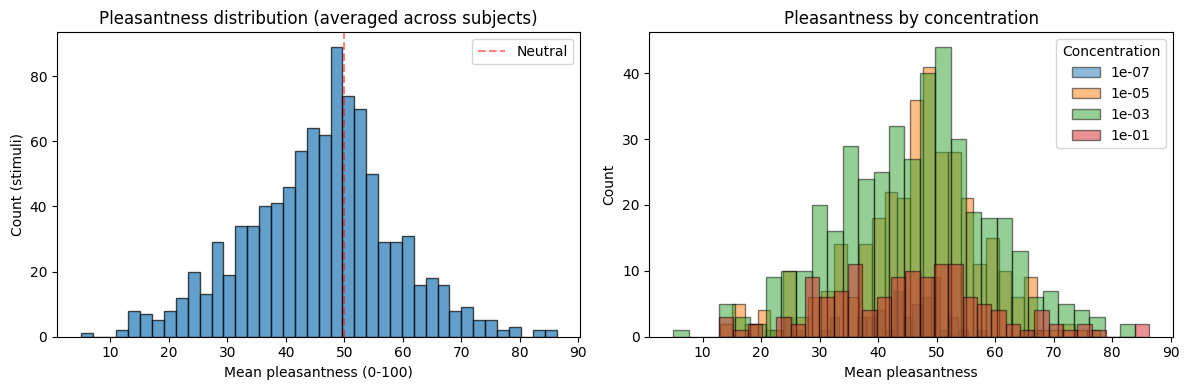

In [30]:
# Pleasantness distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pleasantness["pleasantness"], bins=40, edgecolor="k", alpha=0.7)
axes[0].set_xlabel("Mean pleasantness (0-100)")
axes[0].set_ylabel("Count (stimuli)")
axes[0].set_title("Pleasantness distribution (averaged across subjects)")
axes[0].axvline(50, color="r", ls="--", alpha=0.5, label="Neutral")
axes[0].legend()

# Pleasantness by concentration
for conc, grp in pleasantness.reset_index().groupby("Concentration"):
    axes[1].hist(grp["pleasantness"], bins=30, alpha=0.5, label=f"{conc:.0e}", edgecolor="k")
axes[1].set_xlabel("Mean pleasantness")
axes[1].set_ylabel("Count")
axes[1].set_title("Pleasantness by concentration")
axes[1].legend(title="Concentration")

plt.tight_layout()
plt.show()

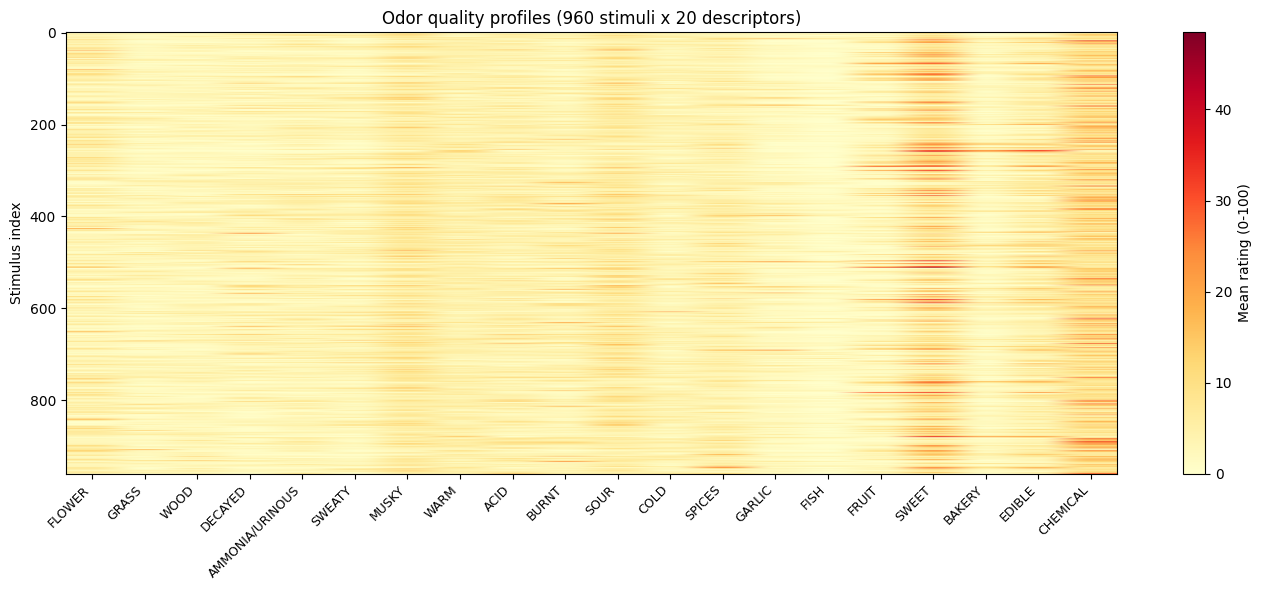

In [31]:
# Quality descriptor heatmap
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(qualities.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(QUALITY_DESCRIPTORS)))
ax.set_xticklabels(QUALITY_DESCRIPTORS, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Stimulus index")
ax.set_title(f"Odor quality profiles ({qualities.shape[0]} stimuli x {qualities.shape[1]} descriptors)")
plt.colorbar(im, ax=ax, label="Mean rating (0-100)")
plt.tight_layout()
plt.show()

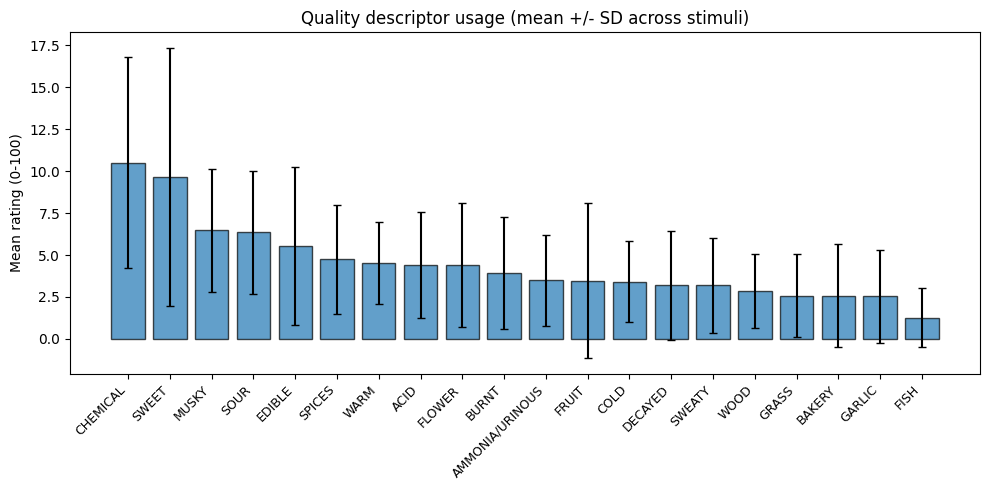

In [32]:
# Mean and variability of each descriptor
desc_means = qualities.mean().sort_values(ascending=False)
desc_stds = qualities.std().reindex(desc_means.index)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(desc_means))
ax.bar(x, desc_means, yerr=desc_stds, capsize=3, edgecolor="k", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(desc_means.index, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Mean rating (0-100)")
ax.set_title("Quality descriptor usage (mean +/- SD across stimuli)")
plt.tight_layout()
plt.show()

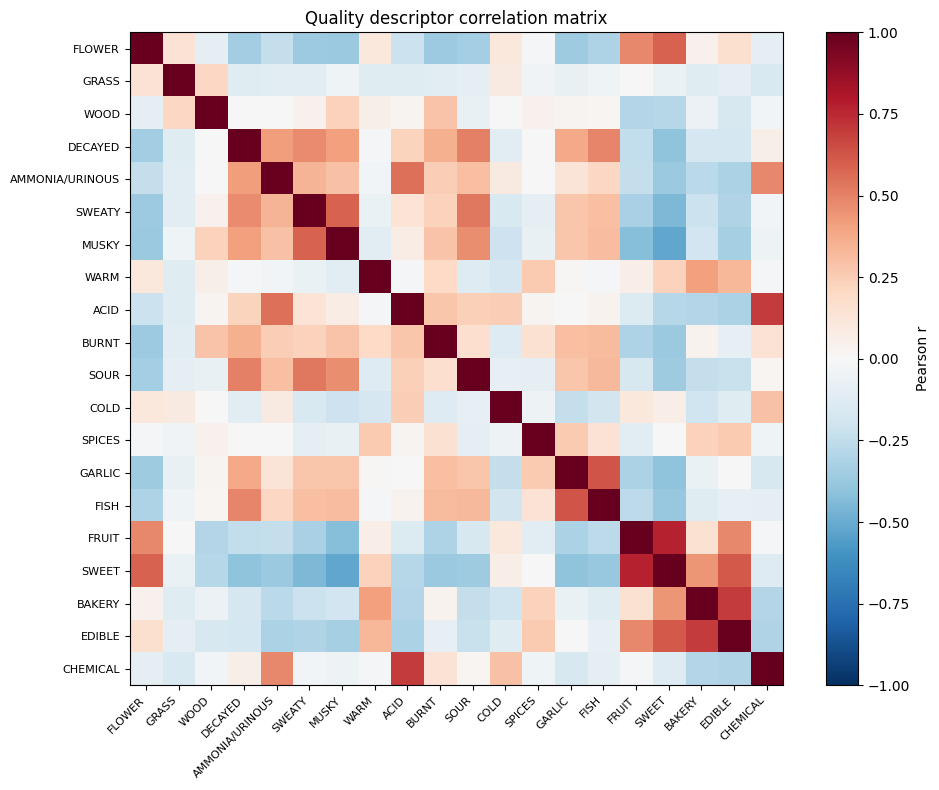

In [33]:
# Correlation between descriptors
corr = qualities.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(QUALITY_DESCRIPTORS)))
ax.set_yticks(range(len(QUALITY_DESCRIPTORS)))
ax.set_xticklabels(QUALITY_DESCRIPTORS, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(QUALITY_DESCRIPTORS, fontsize=8)
ax.set_title("Quality descriptor correlation matrix")
plt.colorbar(im, ax=ax, label="Pearson r")
plt.tight_layout()
plt.show()

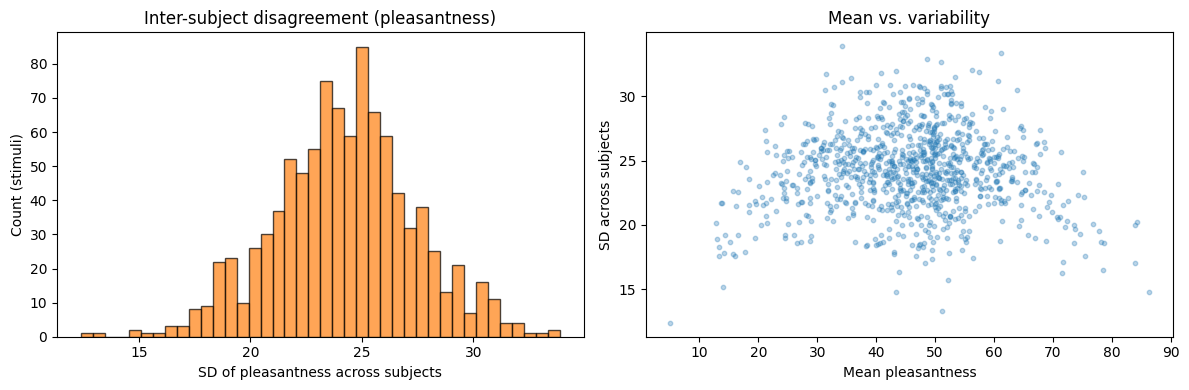

In [34]:
# Subject-level variability: how much do subjects agree?
# Compute per-stimulus SD across subjects for pleasantness
pleas_var = ratings_wide.groupby(["Stimulus", "CID", "Concentration"])["HOW PLEASANT IS THE SMELL?"].agg(["mean", "std", "count"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pleas_var["std"], bins=40, edgecolor="k", alpha=0.7, color="C1")
axes[0].set_xlabel("SD of pleasantness across subjects")
axes[0].set_ylabel("Count (stimuli)")
axes[0].set_title("Inter-subject disagreement (pleasantness)")

axes[1].scatter(pleas_var["mean"], pleas_var["std"], alpha=0.3, s=10)
axes[1].set_xlabel("Mean pleasantness")
axes[1].set_ylabel("SD across subjects")
axes[1].set_title("Mean vs. variability")

plt.tight_layout()
plt.show()

## 6. ML readiness checks

In [35]:
print("=" * 55)
print("ML TARGET READINESS")
print("=" * 55)

print(f"\nQuality matrix:  {qualities.shape}")
print(f"  NaN:           {qualities.isna().sum().sum()}")
print(f"  Value range:   [{qualities.values.min():.2f}, {qualities.values.max():.2f}]")
print(f"  Zero columns:  {(qualities.var() < 1e-10).sum()}")

print(f"\nPleasantness:    {pleasantness.shape}")
print(f"  NaN:           {pleasantness.isna().sum().sum()}")
print(f"  Value range:   [{pleasantness.values.min():.2f}, {pleasantness.values.max():.2f}]")

# Check alignment with spectra (ensure matching int types)
spectra_matrix = pd.read_csv(DATA_DIR / "ir_spectra_matrix.csv", index_col=0)
spectra_cids = set(int(c) for c in spectra_matrix.index)
target_cids = set(int(c) for c in qualities.reset_index()["CID"].unique())
overlap = spectra_cids & target_cids

print(f"\nAlignment with IR spectra:")
print(f"  Spectra CIDs:  {len(spectra_cids)}")
print(f"  Target CIDs:   {len(target_cids)}")
print(f"  Overlap:       {len(overlap)} ({100*len(overlap)/len(spectra_cids):.1f}% of spectra)")
print(f"  -> ML-ready pairs: {len(overlap)} odorants x 2 conc = {len(overlap)*2} samples")

print("\n" + "=" * 55)

ML TARGET READINESS

Quality matrix:  (960, 20)
  NaN:           0
  Value range:   [0.00, 48.47]
  Zero columns:  0

Pleasantness:    (960, 1)
  NaN:           0
  Value range:   [4.96, 86.28]

Alignment with IR spectra:
  Spectra CIDs:  234
  Target CIDs:   480
  Overlap:       234 (100.0% of spectra)
  -> ML-ready pairs: 234 odorants x 2 conc = 468 samples



## 7. Save targets

In [36]:
qualities.to_csv(DATA_DIR / "keller_qualities.csv")
pleasantness.to_csv(DATA_DIR / "keller_pleasantness.csv")

print("Saved:")
print(f"  keller_qualities.csv     : {qualities.shape[0]} stimuli x {qualities.shape[1]} descriptors")
print(f"  keller_pleasantness.csv  : {pleasantness.shape[0]} stimuli x 1")
print(f"  keller_ratings_long.csv  : {ratings_wide.shape[0]} subject-level rows (saved earlier)")

Saved:
  keller_qualities.csv     : 960 stimuli x 20 descriptors
  keller_pleasantness.csv  : 960 stimuli x 1
  keller_ratings_long.csv  : 39884 subject-level rows (saved earlier)
